**Test TridiagonalMatrices Instance:**

In [1]:
import numpy as np
from FunctionDenoising import TridiagonalMatrices

n = 6
a = np.full(n, 2.0)
b = np.full(n-1, -1.0)
c = b

T = TridiagonalMatrices(a, b, c)

# Test 1: print dense 2D NumPy array and verify correctness
print("Dense Matrix with n=6:")
print(T.dense_rep)

print("-"*50)

# Test 2: Sparse product vs NumPy product
x = np.random.default_rng(0).standard_normal(n)

sparse_prod = T.matvec_prod(x)
numpy_prod = T.dense_rep @ x

print("The results match:", np.allclose(sparse_prod, numpy_prod))




Dense Matrix with n=6:
[[ 2. -1.  0.  0.  0.  0.]
 [-1.  2. -1.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0. -1.  2. -1.]
 [ 0.  0.  0.  0. -1.  2.]]
--------------------------------------------------
The results match: True


**Test LU Decomposition:**

In [2]:
import numpy as np
from FunctionDenoising import TridiagonalMatrices

n = 10
a = np.full(n, 2.0)
b = c = np.full(n-1, -1.0)

T = TridiagonalMatrices(a, b, c)
T.lu_decomp() # compute and store alpha and beta before calling error


print("||A - LU|| =", T.error())

||A - LU|| = 0.0


**Test Efficiency/Time complexity:**

**Theoretical complexity:**

Each iteration of the loop in the lu_decomp function performs 3 operations (1 division, 1 subtraction, 1 multiplication). Since the loop runs $n-1$ times, the total number of operations is: $$3(n - 1) = 3n - 3$$

So, the theoretical complexity is $O(n)$, with constant 3 multiplying the highest power of $n$.

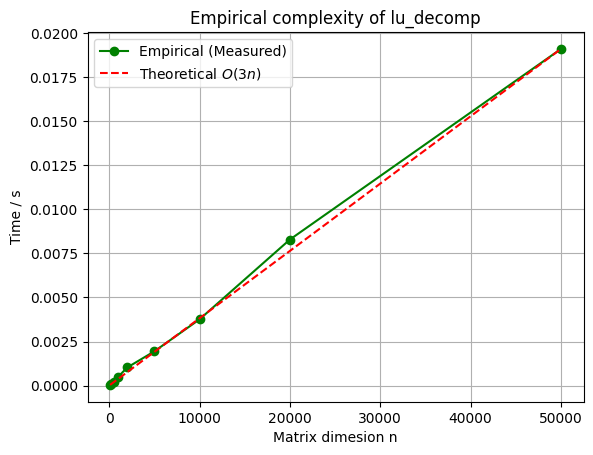

In [3]:
import numpy as np
from FunctionDenoising import TridiagonalMatrices
import time
import matplotlib.pyplot as plt

sizes = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000] # n values
times = []

# Measure the execution time of lu_decomp for each value of n
for n in sizes:
    a = np.full(n, 2.0)
    b = c = np.full(n-1, -1.0)
    T = TridiagonalMatrices(a, b, c)
    
    start = time.time()
    T.lu_decomp()
    times.append(time.time() - start)

# To compare seconds (y-axis) with operations (3n), we calculate a scaling constant 'k'.
k = times[-1] / (3 * sizes[-1])
# Theoretical 3n line scaled by k to fit the y-axis
theoretical_3n = [k * 3 * n for n in sizes]

# plot measured empirical data
plt.plot(sizes, times, marker = 'o', color = 'green', label = 'Empirical (Measured)')
# plot theoretical O(3n) line to verify linearity of empirical data
plt.plot(sizes, theoretical_3n, linestyle = '--', color = 'red', label = 'Theoretical $O(3n)$')

# Labels, titles, legend, according to scientific programming standards
plt.xlabel('Matrix dimesion n')
plt.ylabel('Time / s')
plt.title('Empirical complexity of lu_decomp')
plt.legend()
plt.grid(True)
plt.show()



**Empirical complexity:**

The timing plot approximately shows linear growth, on a similar scale, which confirms $O(n)$ empirically

**Comparison between theoretical and empirical, and explanation of differences:**

The empirical and theoretical complexity agree in terms of order, as both are $O(n)$, however the empirical constant is larger than 3 because:

- The theoretical count only measures arithmetic operations

- In practice, the Python 'for' loop adds overhead per iteration that is not taken into account by operation counting (each array access (alpha[i], self._b[i-1], etc) inside a Python loop is slower than it would be in a fully vectorised operation)

So, the algorithm scales linearly as predicted, however it runs slower in practice than the theoretical constant, 3, suggests.

**Test Linear System Solver:**

In [4]:
import numpy as np
from FunctionDenoising import TridiagonalMatrices

# Setuo for n = 100
n = 100
a = np.full(n, 2.0)
b = c = np.full(n-1, -1.0)
A = TridiagonalMatrices(a, b, c)

# Create random vector b
b_rhs = np.random.rand(n)

# Compute my result
x_solution = A.solvelinearsystem(b_rhs)

# Verification 1: |b - Ax|
Ax_solution = A.matvec_prod(x_solution)
difference1 = b_rhs - Ax_solution
error1 = np.sqrt(np.sum(difference1 ** 2))
print("Verification error |b - Ax| :", error1)


# Verification 2: Comparison with NumPy
A_dense = A.dense_rep
x_numpy = np.linalg.solve(A_dense, b_rhs)
difference2 = x_solution - x_numpy
error2 = np.sqrt(np.sum(difference2 ** 2))
print("Difference from Numpy solution :", error2)







Verification error |b - Ax| : 6.125968299376993e-13
Difference from Numpy solution : 1.1273695948508458e-12


**Test Efficiency/Time Complexity:**

**Theoretical complexity:**

The loops thas dominate the complexity of the solvelinearsystem function consists of two parts: Forward substitution and backward substitution. 

- Each iteration of the forward substitution loop performs 2 operations
- Each iteration of the backward substitution loop performs 3 operations

$$2n + 3n = 5n$$

So, the theoretical complexity is $O(n)$, with constant 5 multiplying the highest power of $n$.

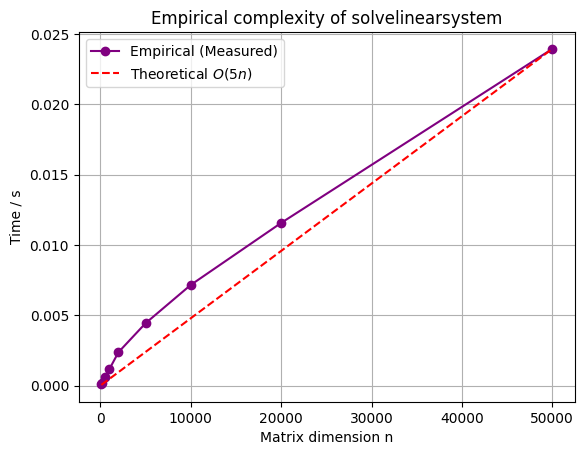

In [2]:
import numpy as np
from FunctionDenoising import TridiagonalMatrices
import time
import matplotlib.pyplot as plt

sizes = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000] # n values
times = []

# Measure the execution time of solvelinearsystem for each value of n
for n in sizes:
    a = np.full(n, 2.0)
    b = c = np.full(n-1, -1.0)
    T = TridiagonalMatrices(a, b, c)

    T.lu_decomp()

    # Create random b
    b_rhs = np.random.rand(n)

    start = time.time()
    # Measure the solving time (forward/backward substitution)
    T.solvelinearsystem(b_rhs)
    times.append(time.time() - start)

# To compare seconds (y-axis) with operations (5n), we calculate a scaling constant 'k', which represents the average time the processor takes for 1 operation.
k = times[-1] / (5 * sizes[-1])
# Theoretical 5n line scaled by k to fit in the y-axis
theoretical_5n = [k * 5 * n for n in sizes]

# plot measured empirical data
plt.plot(sizes, times, marker = 'o', color = 'purple', label = 'Empirical (Measured)')
# plot theoretical O(5n) line to verify linearity of empirical data
plt.plot(sizes, theoretical_5n, linestyle = '--', color = 'red', label = 'Theoretical $O(5n)$')

# Labels, titles, legend, according to scientific programming standards
plt.xlabel('Matrix dimension n')
plt.ylabel('Time / s')
plt.title('Empirical complexity of solvelinearsystem')
plt.legend()
plt.grid(True)
plt.show()





**Empirical complexity:**

The timing plot approximately shows linear growth, on a similar scale, which confirms $O(n)$ empirically

**Comparison between theoretical and empirical, and explanation of differences:**

The empirical and theoretical complexity agree in terms of order, as both are $O(n)$, however the empirical constant is larger than 5 because:

- The theoretical count only measures arithmetic operations

- In practice, the Python 'for' loop adds overhead per iteration that is not taken into account by operation counting (each array access self._beta[i-1], self._alpha[i], etc) inside a Python loop is slower than it would be in a fully vectorised operation).

So, the algorithm scales linearly as predicted, however it runs slower in practice than the theoretical constant, 5, suggests.

**Approximation of Space Complexity:**

A dense $n$ x $n$ matrix stores every single entry in the matrix, regardless of whether it is zero or non-zero. Hence, the memory required in equal to the total number of entries : $$n * n = n^2$$

So, the space complexity for a dense matrix is $O(n^2)$, with constant 1 multiplying the leading order term

The sparse representation only stores the non-zero entries. For a tridiagonal matrix, these are the main, lower and upper diagonals:

- Main diagonal ($a$): $n$ entries
- Lower diagonal ($b$): $n-1$ entries
- Upper diagonal ($c$): $n-1$ entries

The total number of stored entries is then: $$n+(n-1)+(n-1)=3n-2$$ The space complexity for a sparse tridiagonal matrix is therefoore O(n), with constant 3 multiplying the leading order term.

**Comparison:** While both representations can store the same mathematical object, the sparse representation becomes significantly more efficient as n grows. In the dense case, memory usage grows quadratically ($n^2$), whereas in the sparse case, memory only grows linearly ($3n$). For example, for a matrix of size $n = 100$, the sparse representation requires $\approx 300$ entries, whereas the dense representation would require $100^2 = 10000$


**Test Noise-adding Function:**

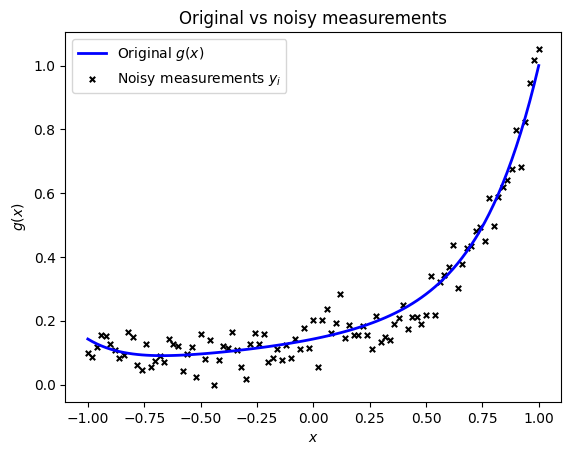

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from FunctionDenoising import FunctionDenoiser

# Test : g(x) from equation (4) with N = 100, sigma = 0.05
def g(x,
     n=6
     ):
    """
    Exact function from equation (4). g(x) = 1/(n+1) * (sum_k=0 -> n x^k)

    Arguments:
        x : Evaluations points
        n: int, polynomial degree (default 6)
    """

    return sum(x**k for k in range(n+1)) / (n+1)

fd = FunctionDenoiser(100)
fd.add_noise(g)
fd.plot()


**Test Smoothing Function:**

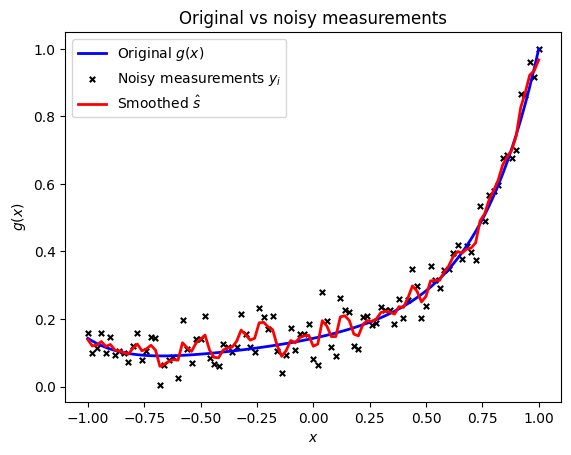

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from FunctionDenoising import FunctionDenoiser

# Test : g(x) from equation (4) with N = 100, sigma = 0.05
def g(x,
     n=6
     ):
    """
    Exact function from equation (4). g(x) = 1/(n+1) * (sum_k=0 -> n x^k)

    Arguments:
        x : Evaluations points
        n: int, polynomial degree (default 6)
    """

    return sum(x**k for k in range(n+1)) / (n+1)

fd = FunctionDenoiser(100)
fd.add_noise(g, 0.05)
fd.smooth(1)
fd.plot()


**Testing Increasing Smoothing Parameters:**

For beta = 10^ 2 :


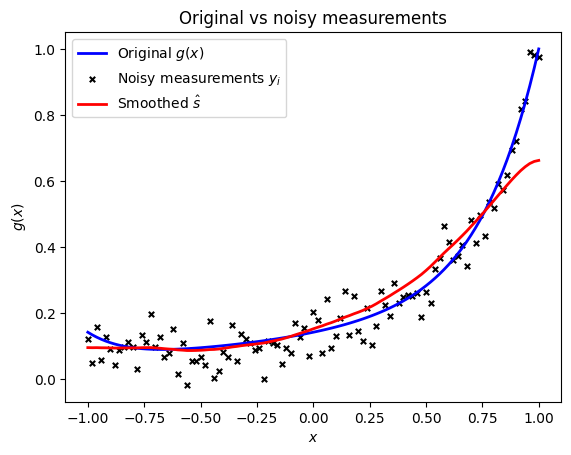

For beta = 10^ 3 :


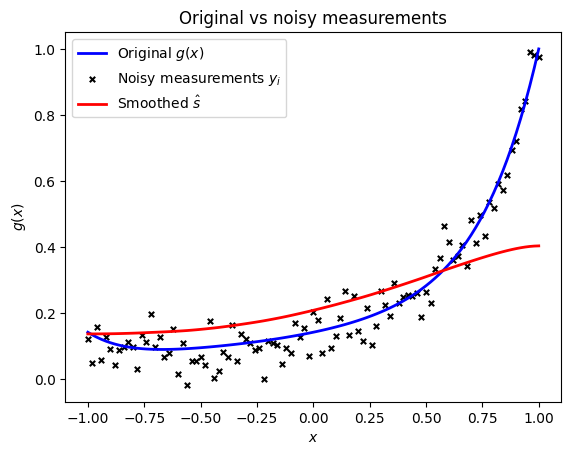

For beta = 10^ 4 :


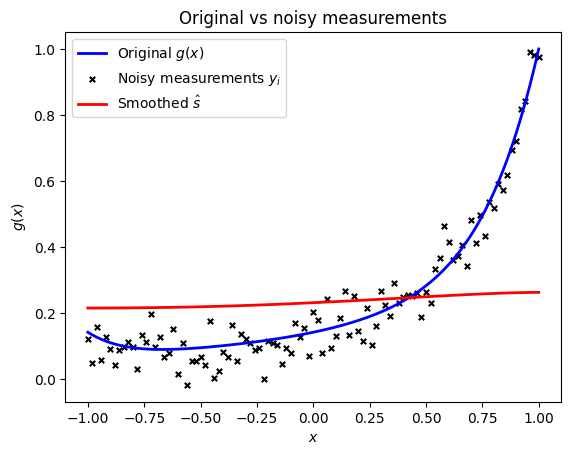

For beta = 10^ 5 :


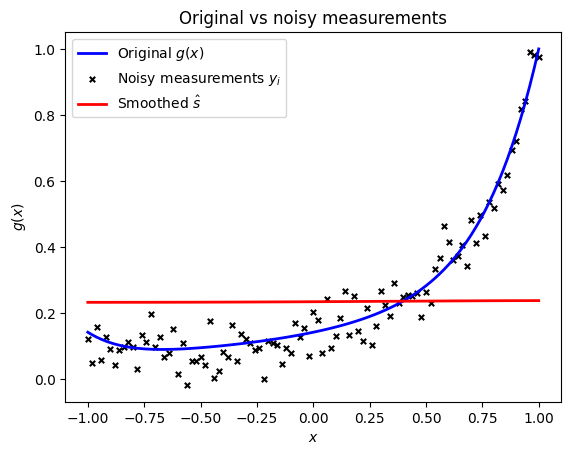

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from FunctionDenoising import FunctionDenoiser

# Test : g(x) from equation (4) with N = 100, sigma = 0.05
def g(x,
     n=6
     ):
    """
    Exact function from equation (4). g(x) = 1/(n+1) * (sum_k=0 -> n x^k)

    Arguments:
        x : Evaluations points
        n: int, polynomial degree (default 6)
    """

    return sum(x**k for k in range(n+1)) / (n+1)

fd = FunctionDenoiser(100)
fd.add_noise(g, 0.05)

for n in [2, 3, 4, 5]:
    fd.smooth(10**(n))
    print("For beta = 10^", n, ":")
    fd.plot()



As $\beta \rightarrow \infty$, the smoothed solution $\hat{s}$ converges to a constant value, equal to the mean of the noisy measurements, seen in the graph as $\approx 2.3$.

**Testing Decreasing Smoothing Parameters:**

For beta = 10^ 1 :


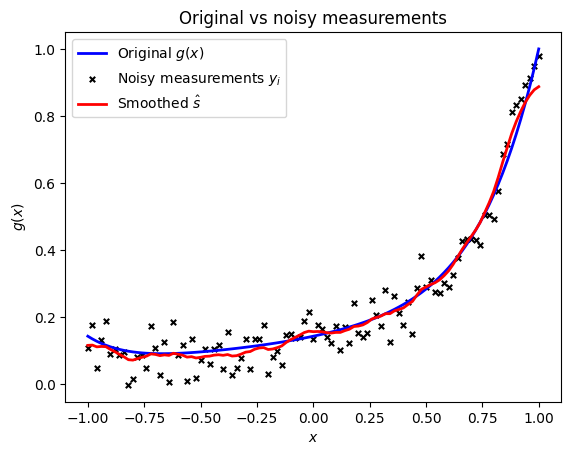

For beta = 10^ 0 :


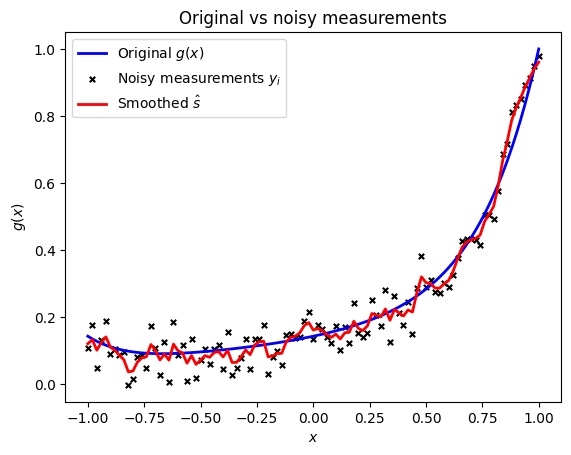

For beta = 10^ -1 :


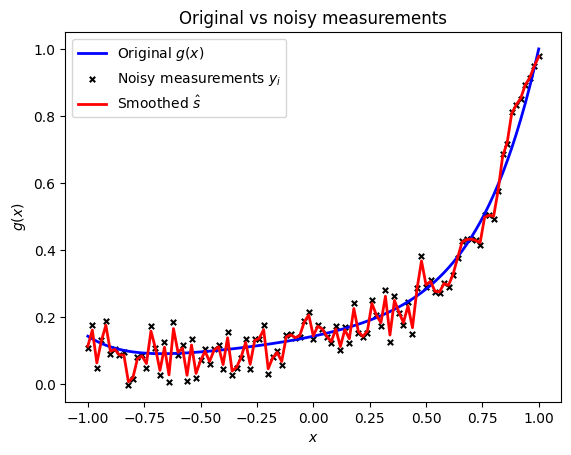

For beta = 10^ -2 :


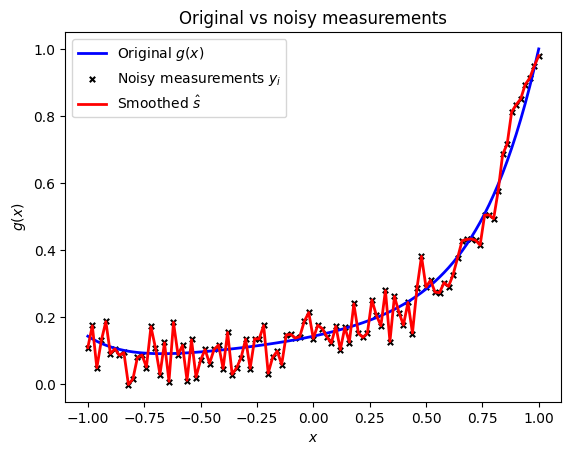

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from FunctionDenoising import FunctionDenoiser

# Test : g(x) from equation (4) with N = 100, sigma = 0.05
def g(x,
     n=6
     ):
    """
    Exact function from equation (4). g(x) = 1/(n+1) * (sum_k=0 -> n x^k)

    Arguments:
        x : Evaluations points
        n: int, polynomial degree (default 6)
    """

    return sum(x**k for k in range(n+1)) / (n+1)

fd = FunctionDenoiser(100)
fd.add_noise(g, 0.05)

for n in [1, 0, -1, -2]:
    fd.smooth(10**(n))
    print("For beta = 10^", n, ":")
    fd.plot()



As $\beta \rightarrow 0$, the smoothed solution $\hat{s}$ converges to the noisy measurements ($\hat{s} = y$). The smoothing term is gone, and the solution fits the data exactly with no regularisation.

**Check Reuse of Hessian and LU decomposition with Cosine and Sine functions, unchanged parameters:**

Smoothing...
Creating tridiagonal Hessian matrix...
LU-decomposing...
Solving linear system...


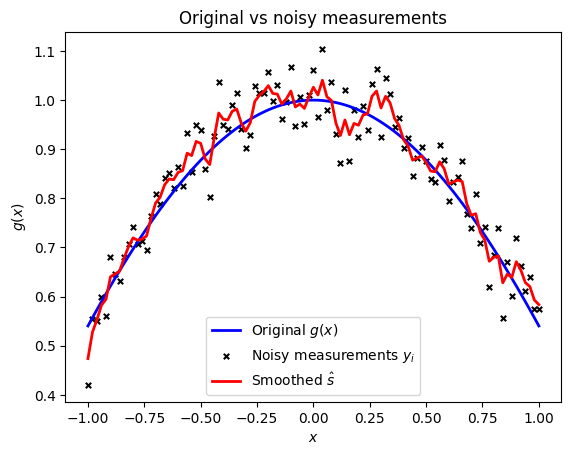


Smoothing...
Solving linear system...


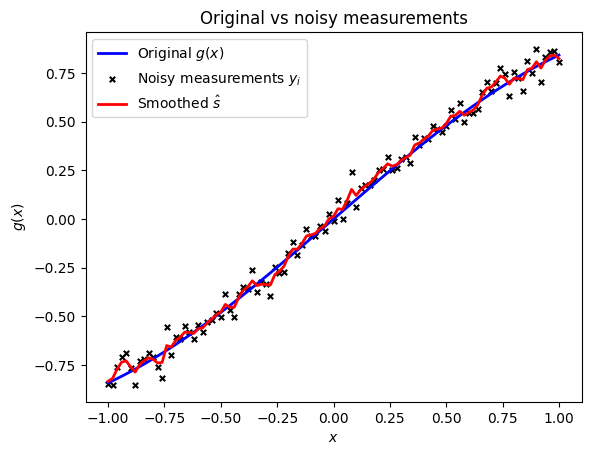

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from FunctionDenoising import FunctionDenoiser

N = 100
sigma = 0.05
fd = FunctionDenoiser(N)
fd.add_noise(np.cos, sigma)
fd.smooth_modified(beta = 1)
fd.plot()
print()
fd.add_noise(np.sin, sigma)
fd.smooth_modified(beta = 1)
fd.plot()

**Test Largest Eigenvalue Function:**

In [11]:
import numpy as np
from FunctionDenoising import TridiagonalMatrices

n = 100
a = np.full(n, 2.0)
b = c = np.full(n-1, -1.0)
A = TridiagonalMatrices(a, b, c)

lambda_powit = A.power_iteration()
lambda_numpy = np.max(np.linalg.eigvals(A.dense_rep))

print("Power iteration largest eigenvalue:", lambda_powit)
print("NumPy eigvals largest eigenvalue:", lambda_numpy)
print("The difference is:", abs(lambda_powit - lambda_numpy))



Power iteration largest eigenvalue: 3.996371681056665
NumPy eigvals largest eigenvalue: 3.9990325645839775
The difference is: 0.0026608835273123077


**Test New Iterative method vs Direct Method:**

Direct method:


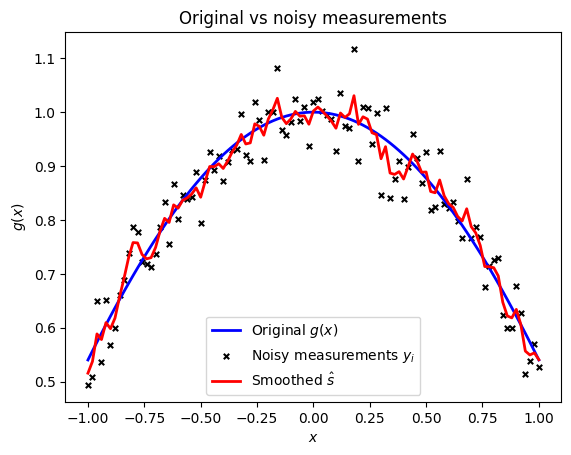

max_iter = 0 : ||s_iter - s_direct|| = 0.3004431682381784


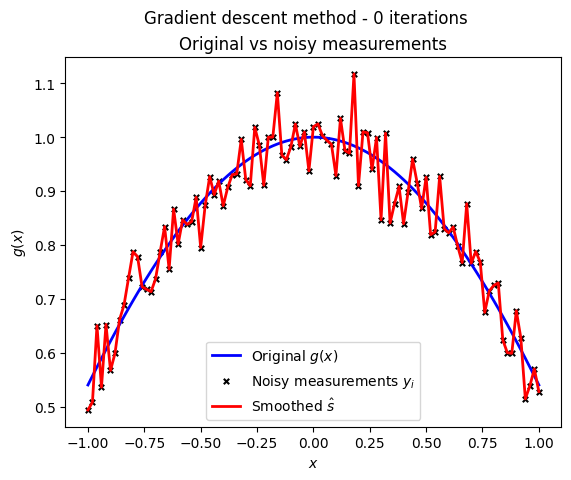

max_iter = 1 : ||s_iter - s_direct|| = 0.08261487937555088


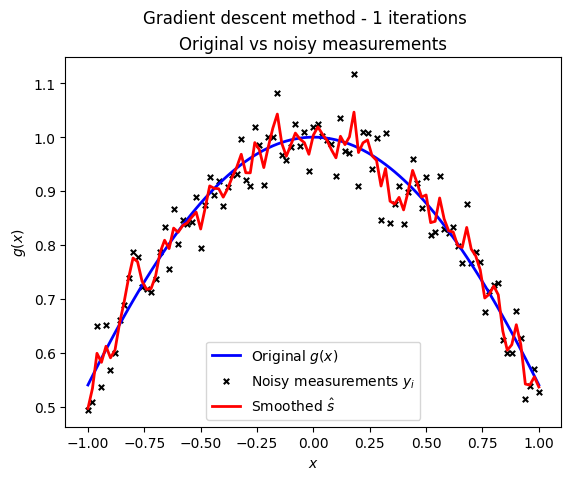

max_iter = 5 : ||s_iter - s_direct|| = 0.011416462554284692


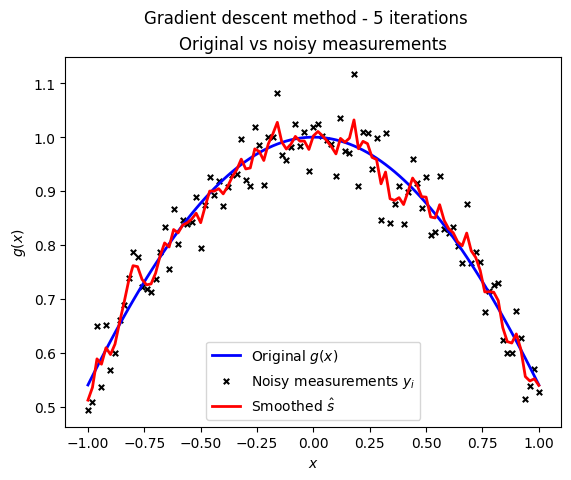

max_iter = 10 : ||s_iter - s_direct|| = 0.002205839706304713


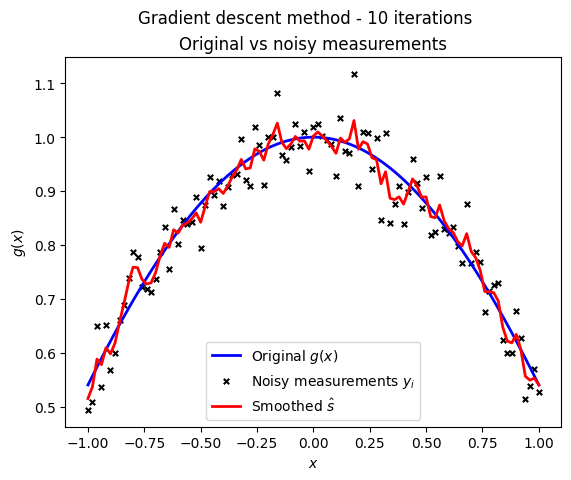

max_iter = 20 : ||s_iter - s_direct|| = 0.00015873224834526628


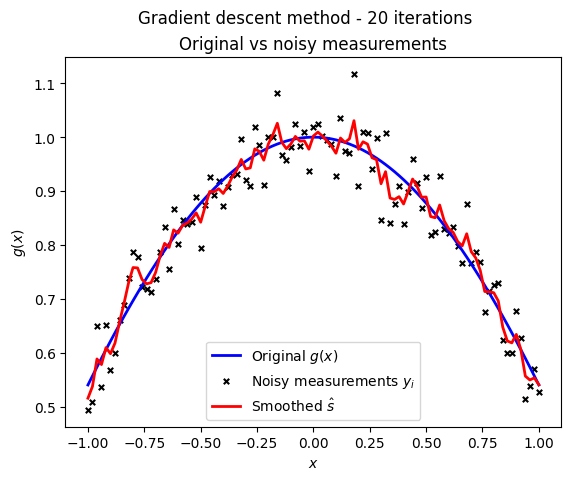

max_iter = 50 : ||s_iter - s_direct|| = 1.29703106170599e-07


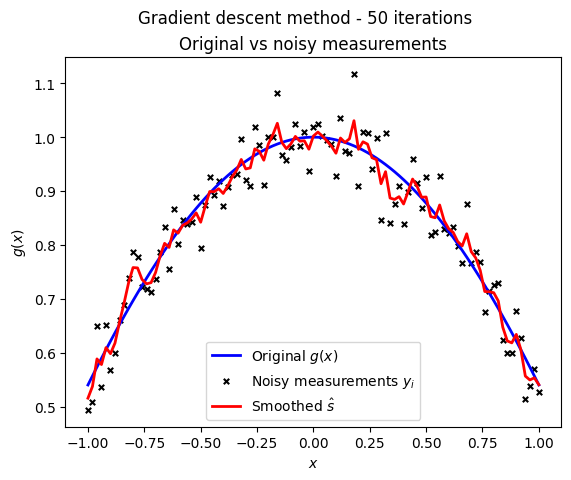

max_iter = 100 : ||s_iter - s_direct|| = 1.3679553472481104e-12


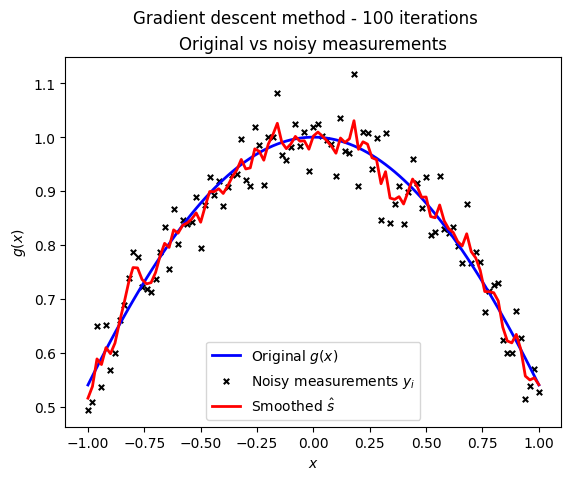

In [12]:
import numpy as np
from FunctionDenoising import FunctionDenoiser, FunctionDenoiserIter

beta = 1
sigma = 0.05

# Compute direct solution
fd_direct = FunctionDenoiser(100)
fd_direct.add_noise(np.cos, sigma)
fd_direct.smooth(beta)

print("Direct method:")
fd_direct.plot()

# Iterative method using the same noisy data
fd_iter = FunctionDenoiserIter(100)
fd_iter.copy_data(fd_direct)

# Increase iterations to verify it gets closer to the direct solution
for max_iter in [0, 1, 5, 10, 20, 50, 100]:

    fd_iter.smooth(beta, max_iter)
    difference = np.sqrt(np.sum((fd_iter.s - fd_direct.s)**2))

    print("max_iter =", max_iter, ": ||s_iter - s_direct|| =", difference)
    fd_iter.plot()


**Compare Direct vs Iterative for Increasing Iterations and Different Smoothing Parameters:**

For beta = 10
1 iterations:


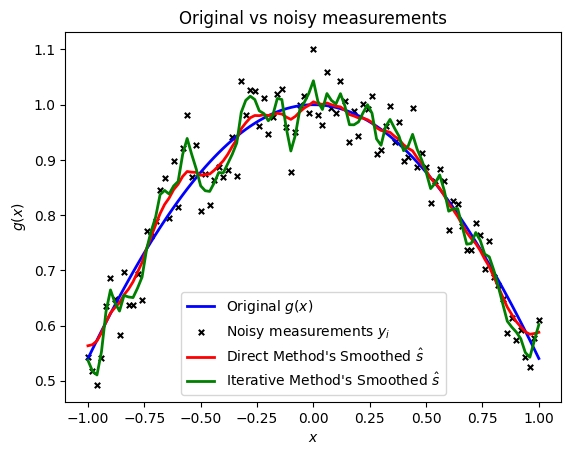

5 iterations:


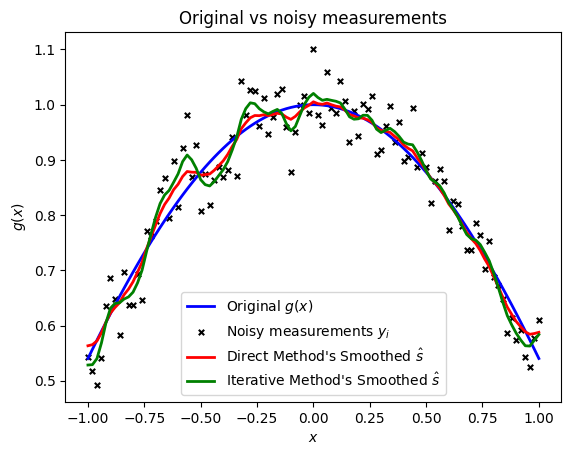

10 iterations:


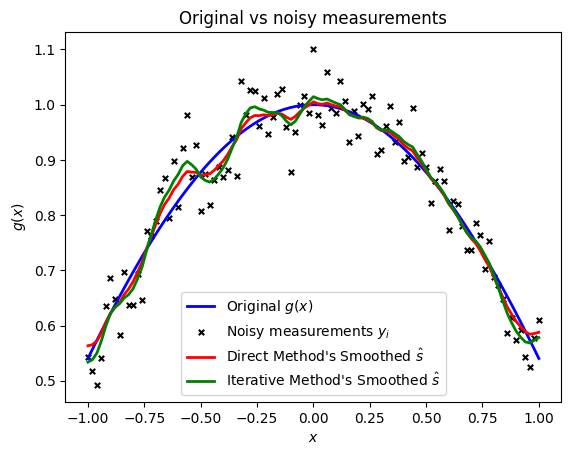

50 iterations:


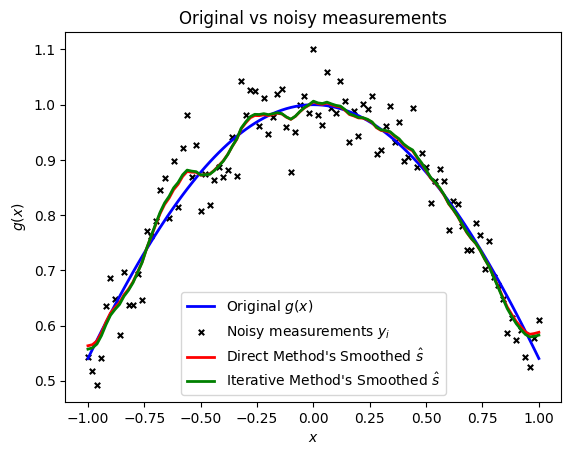

100 iterations:


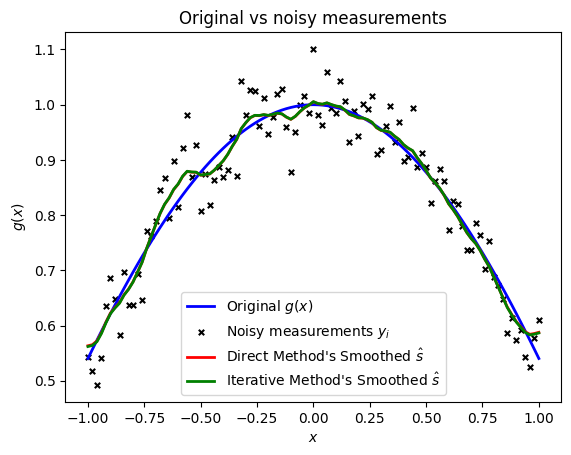

500 iterations:


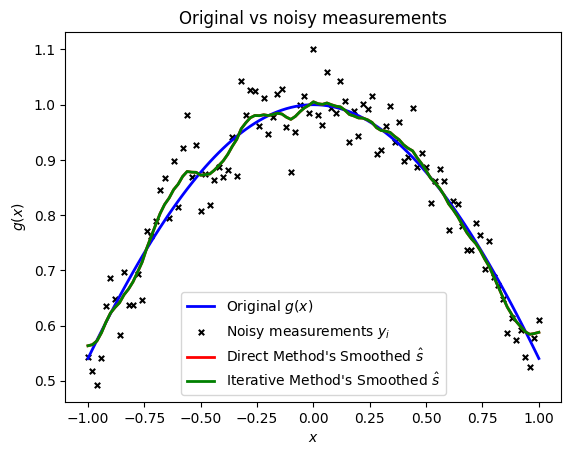

For beta = 100
1 iterations:


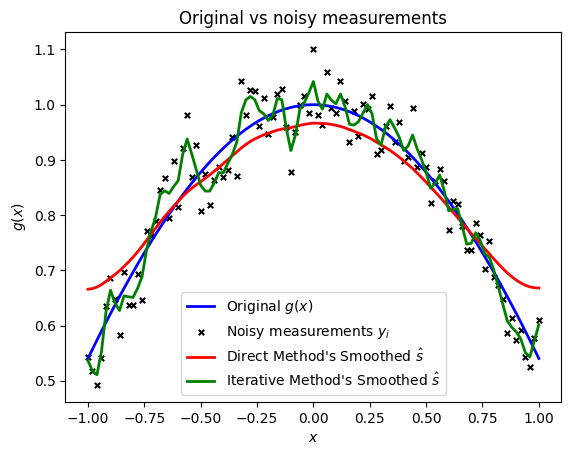

5 iterations:


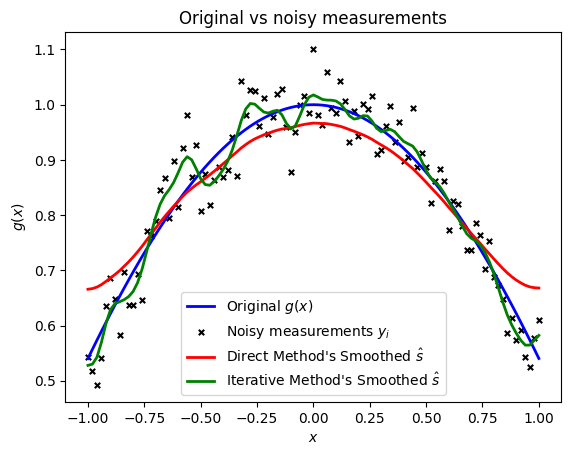

10 iterations:


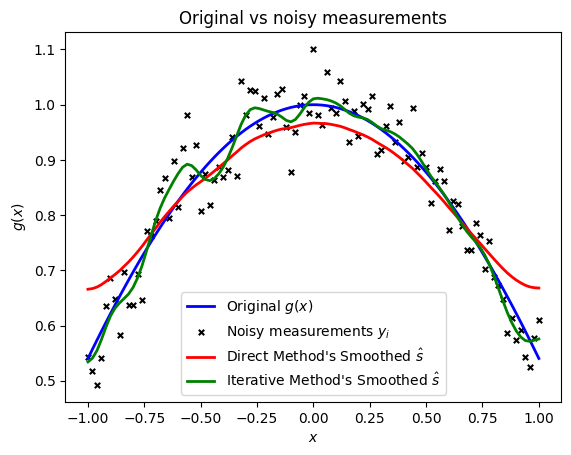

50 iterations:


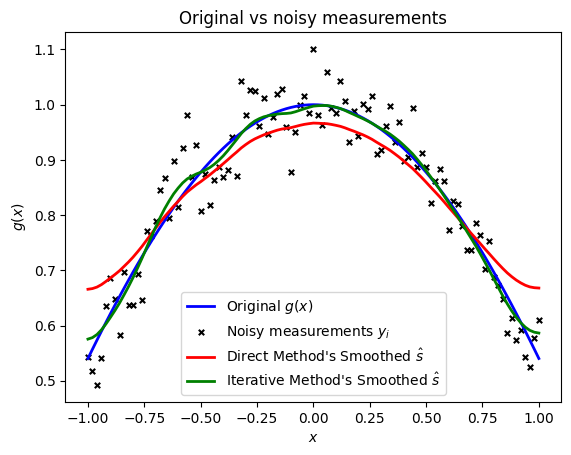

100 iterations:


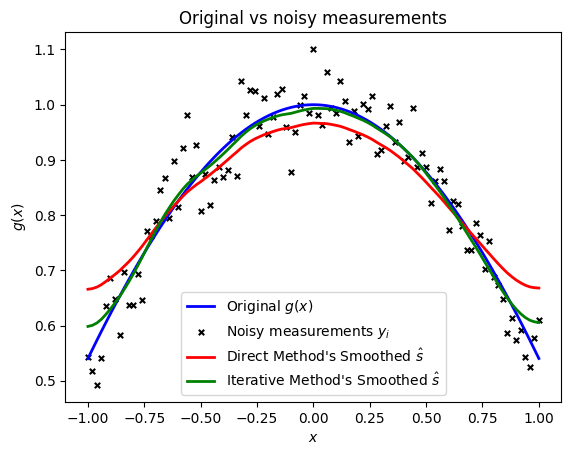

500 iterations:


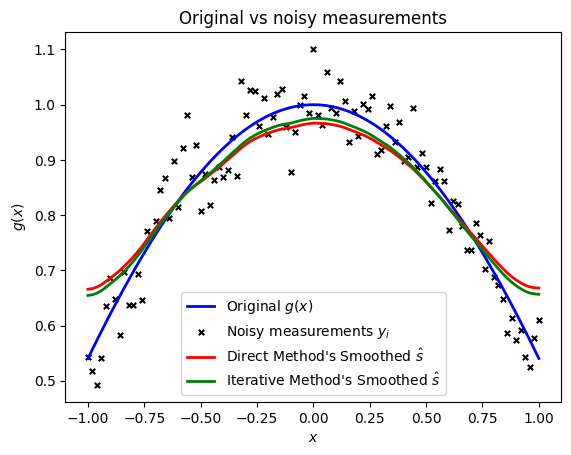

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from FunctionDenoising import FunctionDenoiser, FunctionDenoiserIter

sigma = 0.05

# Initialise instances and create noisy data
fd_direct = FunctionDenoiser(100)
fd_direct.add_noise(np.cos, sigma)

fd_iter = FunctionDenoiserIter(100)
fd_iter.copy_data(fd_direct) # Copy noisy data

# Increase iterations to verify it gets closer to the direct solution
for beta in [10, 100]:

    print("For beta =", beta)

    for max_iter in [1, 5, 10, 50, 100, 500]:

        print(max_iter, "iterations:")
        
        plt.plot(fd_direct.x, fd_direct.y_noiseless, linewidth = 2, color = 'blue', label = "Original $g(x)$") # plot original function
        plt.scatter(fd_direct.x, fd_direct.y, s = 15, marker = 'x', color = 'black', label = "Noisy measurements $y_i$") # plot noisy data

        fd_direct.smooth(beta) # Run function
        plt.plot(fd_direct.x, fd_direct.s, linewidth = 2, color = 'red', label = "Direct Method's Smoothed $\\hat{s}$") # plot direct method's result

        fd_iter.smooth(beta, max_iter)
        plt.plot(fd_iter.x, fd_iter.s, linewidth = 2, color = 'green', label = "Iterative Method's Smoothed $\\hat{s}$") # plot iterative method's result`
        
        plt.xlabel("$x$")
        plt.ylabel("$g(x)$")
        plt.title("Original vs noisy measurements")
        plt.legend()
        plt.show()
    
     


**Interpretation of Results:**

As for the iterations, observing the graph shows that the iterative method gets closer and closer to the direct method as the maximum number of operations increases, which proves that the gradient descent algorithm is correctly converging.

As for $\beta$, it is clear that is has an effect on convergence speed, as when $\beta = 10$, the graphs of the direct method and iterative method look almost identical to the naked eye after 50 iterations, however, when $\beta = 100$, the graphs are still noticibly slightly different even after 500 iterations.

**Efficiency/Time Complexity of Iterative Method:**

Looking into the for-loop that dominates the complexity of the gradient descent algorithm, for each iteration of the loop you are computing:

- The Hessian.matvec_prod(s) function, of complexity $5n$
- Subtraction self.y to compute the gradient, complexity $n$
- Updating $s = s - \alpha * grad$, complexity $2n$

This yields a total complexity per iteration of: $$5n+ n + 2n = 8n$$

So, if the total number of iterations is k, the theoretical complexity of the gradient descent algorithm is $O(k*8n)$, with a scaling constant 8k.

Compared to the complexity of the direct solver, which we before concluded to be $O(5n)$, it is clear that the direct solver is much more efficient than the gradient descent, as even though they are of the same order, $n$, a single iteration of the gradient descent method is complexity-wise equivalent to the entirety of the direct solver method, meaning the latter algorithm is much more efficient. So, in practice, I would choose the direct solver method any day.


**Extra: Image Denoising:**

Building new Hessian...
Solving Linear system...


<Figure size 640x480 with 0 Axes>

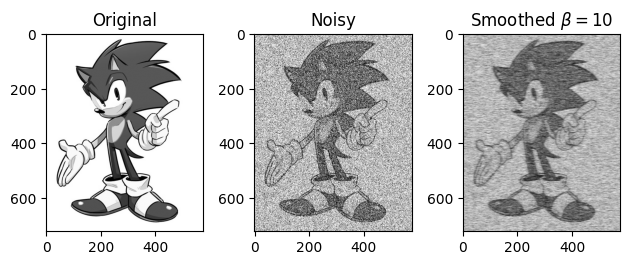

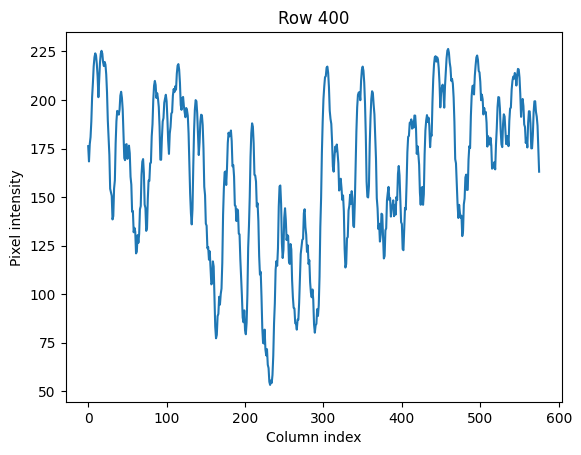

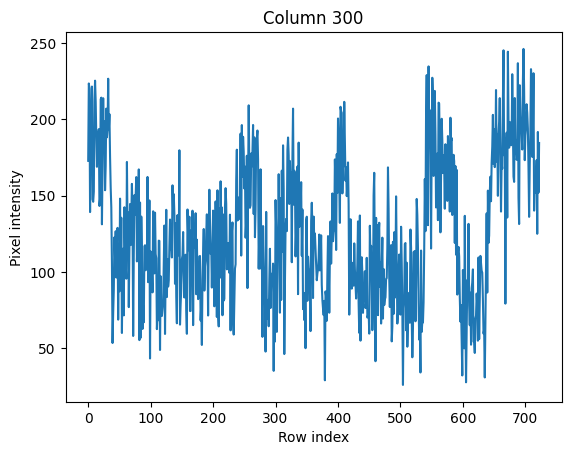

Solving Linear system...


<Figure size 640x480 with 0 Axes>

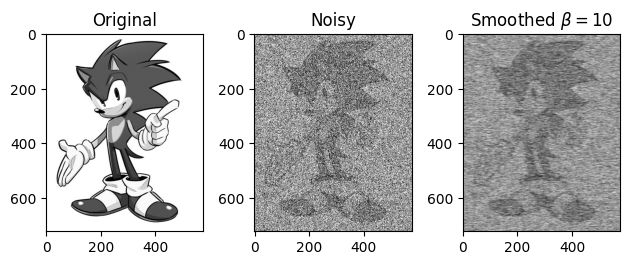

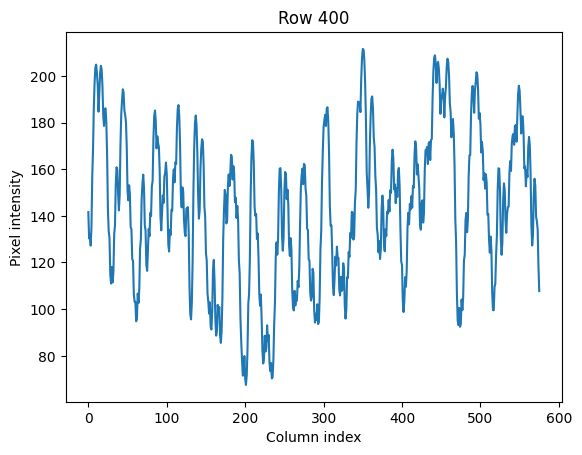

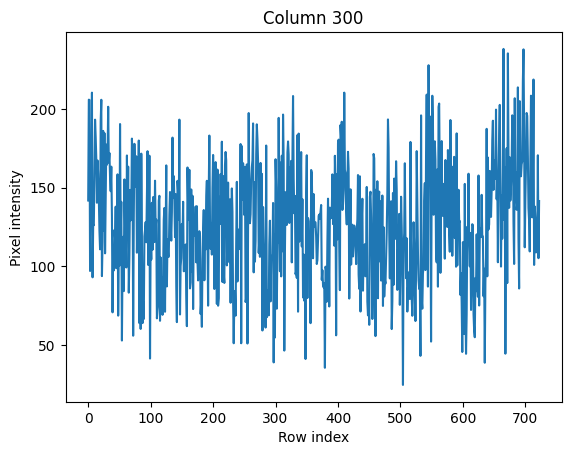

In [3]:
%reset -f
from FunctionDenoising import ImageDenoiser

fd = ImageDenoiser(path="./", file="sonic.jpg")
fd.add_noise(sigma = 2.0)
fd.smooth(beta = 10)
fd.plot()
fd.add_noise(sigma = 5.0)
fd.smooth(beta = 10)
fd.plot()
